In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from scipy.stats import mannwhitneyu
import re

# 1. Chuẩn bị dữ liệu cho cột 'title'
df = pd.read_csv("WELFake_Dataset.csv", encoding = "utf-8")
# Loại bỏ các dòng bị thiếu ở cột title hoặc label để tránh lỗi [cite: 140]
df = df.dropna(subset=['title', 'label']).copy()

## 2.3.2 Phân tích thống kê văn bản (Text EDA)

In [2]:
def analyze_length_and_test(series, labels, title_name="Văn bản"):
    # Tính toán độ dài
    word_counts = series.apply(lambda x: len(str(x).split()))
    
    temp_df = pd.DataFrame({'word_count': word_counts, 'label': labels})
    
    # Vẽ biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(data=temp_df, x='word_count', hue='label', kde=True, ax=axes[0], palette='viridis')
    axes[0].set_title(f'Phân phối số từ - {title_name}')
    
    sns.boxplot(data=temp_df, x='label', y='word_count', ax=axes[1], palette='viridis')
    axes[1].set_title(f'Boxplot độ dài - {title_name}')
    plt.show()
    
    # Kiểm định Mann-Whitney U
    group0 = temp_df[temp_df['label'] == 0]['word_count']
    group1 = temp_df[temp_df['label'] == 1]['word_count']
    stat, p = mannwhitneyu(group0, group1)
    
    print(f"--- Kiểm định Mann-Whitney U ({title_name}) ---")
    print(f"P-value: {p:.4e}")
    print("Kết luận:", "Có khác biệt đáng kể" if p < 0.05 else "Không có khác biệt đáng kể")
    
def analyze_vocab_and_cloud(series, labels, title_name="Văn bản"):
    def get_info(text_data):
        # Kết hợp văn bản, viết thường và tách từ có độ dài >= 3 [cite: 147]
        all_text = ' '.join(text_data.astype(str)).lower()
        tokens = re.findall(r'\b[a-z]{3,}\b', all_text)
        # Tính Type-Token Ratio (TTR) theo yêu cầu đồ án [cite: 144]
        ttr = len(set(tokens)) / len(tokens) if tokens else 0
        return tokens, ttr

    # Tách dữ liệu theo nhãn: 0 (Real) và 1 (Fake) [cite: 141]
    tokens0, ttr0 = get_info(series[labels == 0])
    tokens1, ttr1 = get_info(series[labels == 1])
    
    # 1. In chỉ số TTR để đánh giá độ phong phú từ vựng [cite: 144]
    print(f"\n{'='*20} PHÂN TÍCH VỐN TỪ: {title_name.upper()} {'='*20}")
    print(f"Chỉ số Type-Token Ratio (TTR) - Độ phong phú từ vựng:")
    print(f" - Nhãn 0 (Real): {ttr0:.4f}")
    print(f" - Nhãn 1 (Fake): {ttr1:.4f}")
    
    # 2. Vẽ WordCloud để trực quan hóa các từ phổ biến nhất [cite: 143]
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for i, (tokens, lbl) in enumerate([(tokens0, "Real"), (tokens1, "Fake")]):
        # Giới hạn 20.000 từ để vẽ cloud nhanh và tránh tràn RAM
        text_for_wc = ' '.join(tokens[:20000])
        bg_color = 'white' if i == 0 else 'black'
        wc = WordCloud(width=600, height=400, background_color=bg_color).generate(text_for_wc)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f"WordCloud {lbl} - {title_name}", fontsize=15)
        axes[i].axis('off')
    plt.show()
    
    # 3. Tạo bảng Top 50 từ phổ biến nhất theo từng lớp [cite: 143]
    top0 = Counter(tokens0).most_common(50)
    top1 = Counter(tokens1).most_common(50)
    
    # Tích hợp dữ liệu vào DataFrame để in dạng bảng
    df_top50 = pd.DataFrame({
        'Real_Word': [item[0] for item in top0],
        'Real_Count': [item[1] for item in top0],
        'Fake_Word': [item[0] for item in top1],
        'Fake_Count': [item[1] for item in top1]
    })
    df_top50.index = df_top50.index + 1 # Đánh số thứ tự từ 1 đến 50
    
    print(f"\nBẢNG TOP 50 TỪ PHỔ BIẾN NHẤT TRONG {title_name.upper()}:")
    # Sử dụng display để hiển thị bảng có định dạng trong Jupyter Notebook [cite: 214]
    from IPython.display import display
    display(df_top50)
    
    return top0, top1


def analyze_zipf(series, labels, title_name="Văn bản"):
    plt.figure(figsize=(10, 6))
    
    for lbl in [0, 1]:
        text = ' '.join(series[labels == lbl].astype(str)).lower()
        tokens = re.findall(r'\b[a-z]{2,}\b', text)
        counts = Counter(tokens)
        freqs = sorted(counts.values(), reverse=True)
        plt.loglog(range(1, len(freqs) + 1), freqs, label=f'Nhãn {lbl}')
    
    # Đường lý tưởng
    plt.loglog([1, 1000], [freqs[0], freqs[0]/1000], '--k', alpha=0.5, label='Ideal Zipf')
    plt.title(f'Định luật Zipf - {title_name}')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

### 2.3.2.1 Title

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1536\3090994457.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='label', y='word_count', ax=axes[1], palette='viridis')


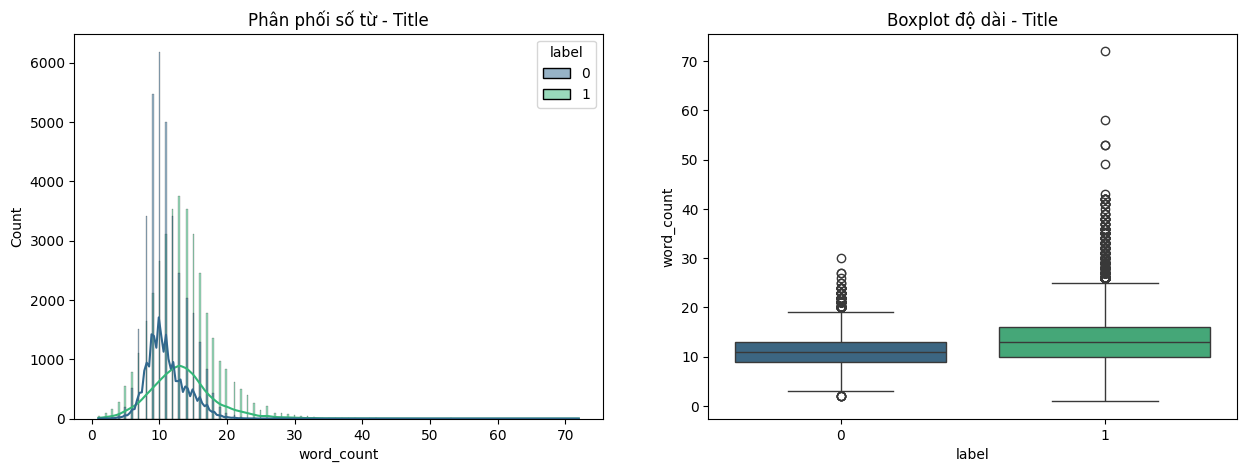

--- Kiểm định Mann-Whitney U (Title) ---
P-value: 0.0000e+00
Kết luận: Có khác biệt đáng kể


In [3]:
# --- PHÂN TÍCH CHO TITLE ---
analyze_length_and_test(df['title'], df['label'], "Title")


==================== PHÂN TÍCH VỐN TỪ: TITLE ====================
Chỉ số Type-Token Ratio (TTR) - Độ phong phú từ vựng:
 - Nhãn 0 (Real): 0.0615
 - Nhãn 1 (Fake): 0.0500


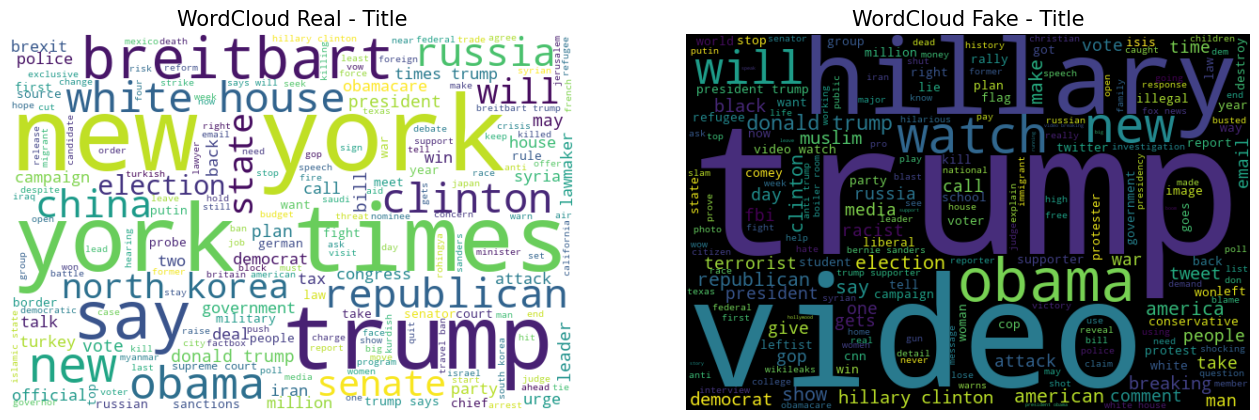


BẢNG TOP 50 TỪ PHỔ BIẾN NHẤT TRONG TITLE:


,Real_Word,Real_Count,Fake_Word,Fake_Count
1,the,9845,trump,11282
2,trump,8513,the,10960
3,new,7704,video,8968
4,york,6481,for,6454
5,times,6366,and,5262
6,for,4443,hillary,3785
7,says,3352,with,3210
8,breitbart,2402,obama,2952
9,with,2307,clinton,2403
10,and,2169,about,2125


In [ ]:
top_real, top_fake = analyze_vocab_and_cloud(df['title'], df['label'], "Title")

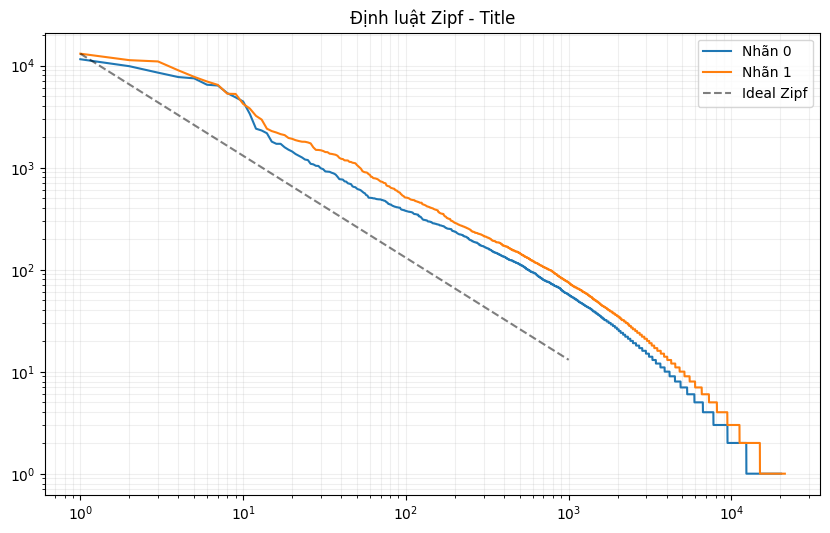

In [5]:
analyze_zipf(df['title'], df['label'], "Title")

# 2.3.2.2 Text

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1536\3090994457.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='label', y='word_count', ax=axes[1], palette='viridis')


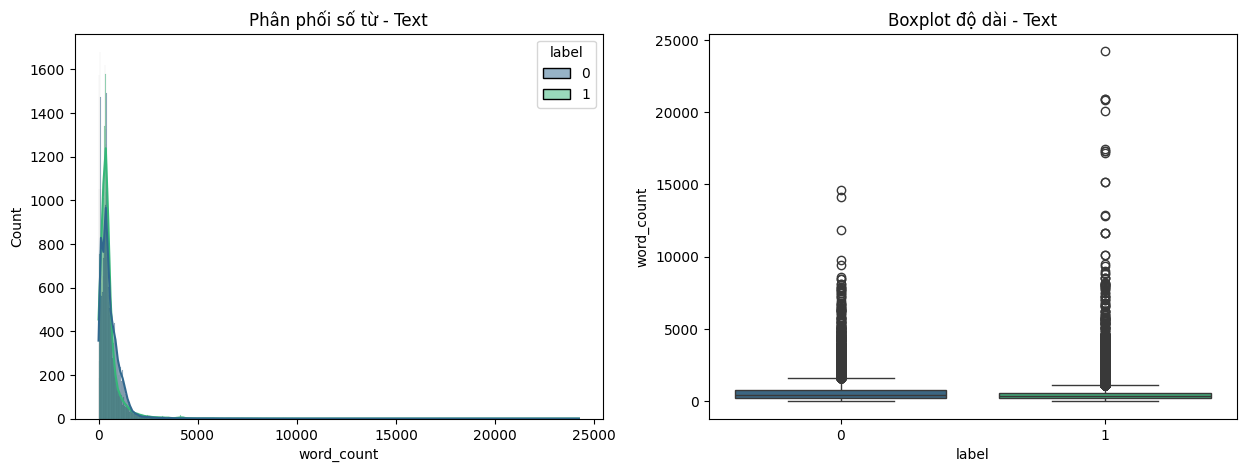

--- Kiểm định Mann-Whitney U (Text) ---
P-value: 1.0281e-170
Kết luận: Có khác biệt đáng kể


In [6]:
# --- PHÂN TÍCH CHO TEXT ---
analyze_length_and_test(df['text'], df['label'], "Text")


==================== PHÂN TÍCH VỐN TỪ: TEXT ====================
Chỉ số Type-Token Ratio (TTR) - Độ phong phú từ vựng:
 - Nhãn 0 (Real): 0.0074
 - Nhãn 1 (Fake): 0.0089


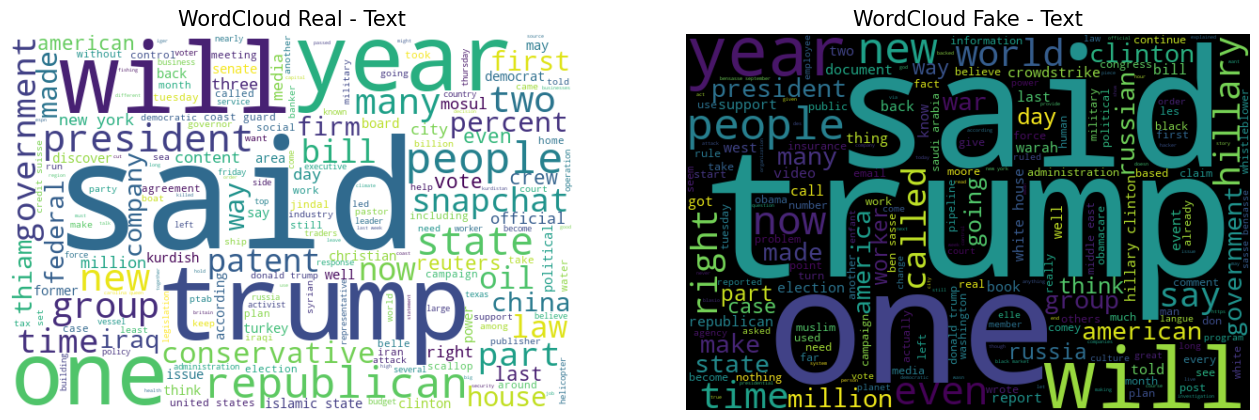


BẢNG TOP 50 TỪ PHỔ BIẾN NHẤT TRONG TEXT:


,Real_Word,Real_Count,Fake_Word,Fake_Count
1,the,1185992,the,1054191
2,and,465218,and,448310
3,that,259158,that,272040
4,for,193669,for,171492
5,said,184607,with,118093
6,with,133629,was,112468
7,was,132623,this,109626
8,trump,107201,trump,106242
9,his,105240,are,98224
10,has,97713,have,88465


In [7]:
top_real_txt, top_fake_txt = analyze_vocab_and_cloud(df['text'], df['label'], "Text")

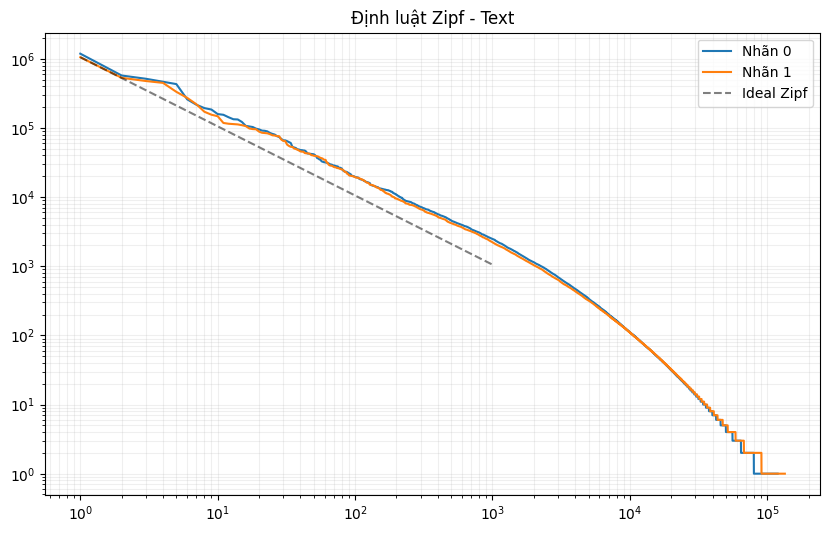

In [8]:
analyze_zipf(df['text'], df['label'], "Text")